#CAR PRICE PREDICTION WITH MACHINE LEARNING 
#BUILDING A REGERESSION MODEL TO PREDICT A SELLING PRICE OF A USED CAR

In [ ]:
# IMPORTING NECESSARY LIBRARIes
# Data manupilation libraries
import numpy as np
import pandas as pd 

# Data visualazation libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Model creation and testing libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

#Converntion and encouding libraries
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder

# Evaluation libraries
from sklearn import metrics
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

#Date Time Libraries 
import datetime

#warning filter library
import warnings
warnings.filterwarnings('ignore')

##DATA COLLECTION AND PREPROCESSING

In [ ]:
df = pd.read_csv('car data.csv')

In [ ]:
#checking the first five rows
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
#checking the last five rows
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [ ]:
#descriptive data analysis
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [ ]:
#checking the dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


##DATA CLEANING

In [ ]:
#checking the number of raws and columns
df.shape

(301, 9)

In [ ]:
#checking for duplicate 
df.duplicated().sum()

2

In [ ]:
#dropping the duplicate
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(299, 9)

In [ ]:
#checking the missing values
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [ ]:
#checking number of columns
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

In [ ]:
# Check unique values and their counts
print(df['Car_Name'].unique())

['ritz' 'sx4' 'ciaz' 'wagon r' 'swift' 'vitara brezza' 's cross'
 'alto 800' 'ertiga' 'dzire' 'alto k10' 'ignis' '800' 'baleno' 'omni'
 'fortuner' 'innova' 'corolla altis' 'etios cross' 'etios g' 'etios liva'
 'corolla' 'etios gd' 'camry' 'land cruiser' 'Royal Enfield Thunder 500'
 'UM Renegade Mojave' 'KTM RC200' 'Bajaj Dominar 400'
 'Royal Enfield Classic 350' 'KTM RC390' 'Hyosung GT250R'
 'Royal Enfield Thunder 350' 'KTM 390 Duke ' 'Mahindra Mojo XT300'
 'Bajaj Pulsar RS200' 'Royal Enfield Bullet 350'
 'Royal Enfield Classic 500' 'Bajaj Avenger 220' 'Bajaj Avenger 150'
 'Honda CB Hornet 160R' 'Yamaha FZ S V 2.0' 'Yamaha FZ 16'
 'TVS Apache RTR 160' 'Bajaj Pulsar 150' 'Honda CBR 150' 'Hero Extreme'
 'Bajaj Avenger 220 dtsi' 'Bajaj Avenger 150 street' 'Yamaha FZ  v 2.0'
 'Bajaj Pulsar  NS 200' 'Bajaj Pulsar 220 F' 'TVS Apache RTR 180'
 'Hero Passion X pro' 'Bajaj Pulsar NS 200' 'Yamaha Fazer '
 'Honda Activa 4G' 'TVS Sport ' 'Honda Dream Yuga '
 'Bajaj Avenger Street 220' 'Hero Splend

In [ ]:
# Check unique values and their counts
print(df['Fuel_Type'].unique())

['Petrol' 'Diesel' 'CNG']


In [ ]:
print(df['Seller_Type'].unique())

['Dealer' 'Individual']


In [ ]:
print(df['Transmission'].unique())

['Manual' 'Automatic']


In [ ]:
print(df['Owner'].unique())

[0 1 3]


#FEATURE ENGENEERING

In [ ]:
# Extract the first word as the car brand
df['Brand'] = df['Car_Name'].str.split().str[0]

In [ ]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Brand
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,ritz
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,sx4
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,ciaz
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,wagon
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,swift


In [ ]:
#culculating vehicle age from year column
current_year = datetime.datetime.now().year

# Create the Car_Age feature
df['Car_Age'] = current_year - df['Year']

In [ ]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Brand,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,ritz,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,sx4,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,ciaz,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,wagon,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,swift,12


#EDA

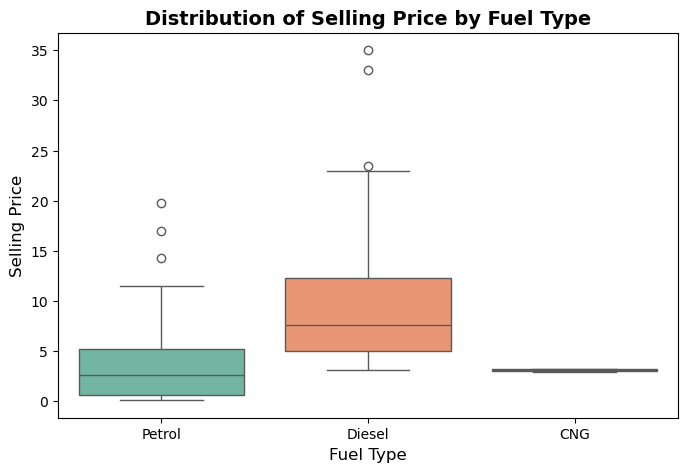

In [ ]:
# Set the figure size
plt.figure(figsize=(8, 5))
# Creating the boxplot
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df, palette='Set2')
# Adding titles and labels
plt.title('Distribution of Selling Price by Fuel Type', fontsize=14, fontweight='bold')
plt.xlabel('Fuel Type', fontsize=12)
plt.ylabel('Selling Price', fontsize=12)
# Displaying the plot
plt.show()

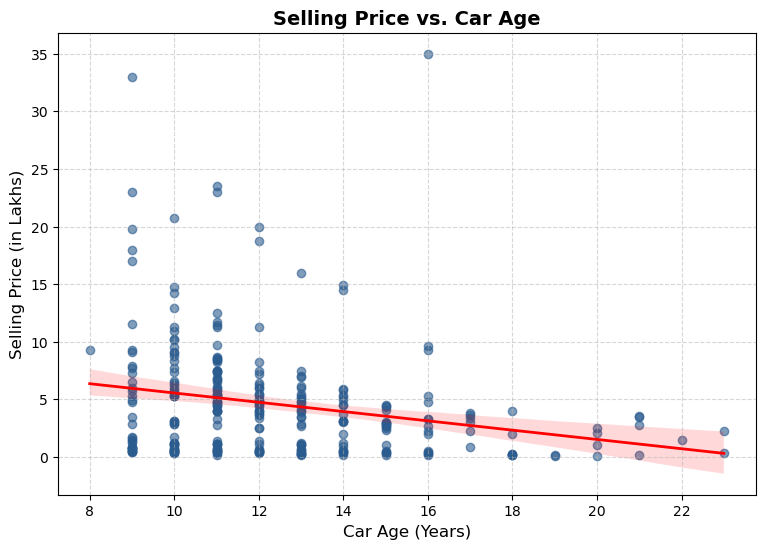

In [ ]:
# Setting the figure size
plt.figure(figsize=(9, 6))

# Creating the scatter plot with a linear trendline
sns.regplot(
    x='Car_Age', 
    y='Selling_Price', 
    data=df, 
    scatter_kws={'alpha': 0.6, 'color': '#2b5c8f'}, 
    line_kws={'color': 'red', 'linewidth': 2}
)

# Setting the labels and title
plt.title('Selling Price vs. Car Age', fontsize=14, fontweight='bold')
plt.xlabel('Car Age (Years)', fontsize=12)
plt.ylabel('Selling Price (in Lakhs)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Displaying the plot
plt.show()

#ENCODING CATEGORICAL VARIABLES INTO NUMERIC

In [ ]:
cat_cols=["Car_Name","Brand","Fuel_Type","Transmission","Seller_Type"]
label_encoders = {}
for col in cat_cols:
    le = preprocessing.LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [ ]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Brand,Car_Age
0,90,2014,3.35,5.59,27000,2,0,1,0,36,12
1,93,2013,4.75,9.54,43000,1,0,1,0,39,13
2,68,2017,7.25,9.85,6900,2,0,1,0,18,9
3,96,2011,2.85,4.15,5200,2,0,1,0,42,15
4,92,2014,4.60,6.87,42450,1,0,1,0,38,12


In [ ]:
df.corr()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Brand,Car_Age
Car_Name,1.000000,0.014713,0.501429,0.474856,0.064077,-0.368454,-0.829255,-0.055072,-0.080579,0.936217,-0.014713
Year,0.014713,1.000000,0.234369,-0.053563,-0.525714,-0.046210,-0.036820,0.003434,-0.181639,-0.036283,-1.000000
Selling_Price,0.501429,0.234369,1.000000,0.876378,0.028566,-0.500292,-0.553851,-0.348869,-0.087880,0.464515,-0.234369
Present_Price,0.474856,-0.053563,0.876378,1.000000,0.205253,-0.431809,-0.511686,-0.334265,0.009947,0.437054,0.053563
Kms_Driven,0.064077,-0.525714,0.028566,0.205253,1.000000,-0.167287,-0.101030,-0.163881,0.089367,0.101843,0.525714
Fuel_Type,-0.368454,-0.046210,-0.500292,-0.431809,-0.167287,1.000000,0.347922,0.068618,0.054174,-0.395757,0.046210
Seller_Type,-0.829255,-0.036820,-0.553851,-0.511686,-0.101030,0.347922,1.000000,0.058669,0.123646,-0.782333,0.036820
Transmission,-0.055072,0.003434,-0.348869,-0.334265,-0.163881,0.068618,0.058669,1.000000,-0.052166,-0.044742,-0.003434
Owner,-0.080579,-0.181639,-0.087880,0.009947,0.089367,0.054174,0.123646,-0.052166,1.000000,-0.057375,0.181639
Brand,0.936217,-0.036283,0.464515,0.437054,0.101843,-0.395757,-0.782333,-0.044742,-0.057375,1.000000,0.036283


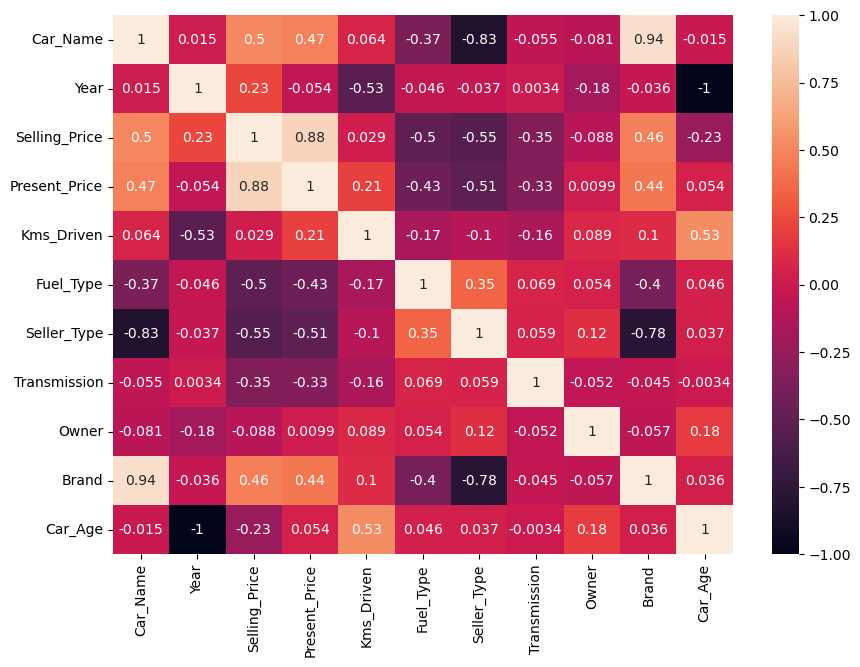

In [ ]:
#visualizing correlation using a heatmap
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True)
plt.show()

#TRAINI TEST SPLIT AND MODEL CREATION

In [ ]:
#separating independ and dependent variables
X=df.drop(["Selling_Price"],axis=1)
Y=df["Selling_Price"]

In [ ]:
print(X)

     Car_Name  Year  Present_Price  Kms_Driven  Fuel_Type  Seller_Type  \
0          90  2014           5.59       27000          2            0   
1          93  2013           9.54       43000          1            0   
2          68  2017           9.85        6900          2            0   
3          96  2011           4.15        5200          2            0   
4          92  2014           6.87       42450          1            0   
..        ...   ...            ...         ...        ...          ...   
296        69  2016          11.60       33988          1            0   
297        66  2015           5.90       60000          2            0   
298        69  2009          11.00       87934          2            0   
299        69  2017          12.50        9000          1            0   
300        66  2016           5.90        5464          2            0   

     Transmission  Owner  Brand  Car_Age  
0               1      0     36       12  
1               1      0 

In [ ]:
print(Y)

0       3.35
1       4.75
2       7.25
3       2.85
4       4.60
       ...  
296     9.50
297     4.00
298     3.35
299    11.50
300     5.30
Name: Selling_Price, Length: 299, dtype: float64


In [ ]:
#splitting my data into train and test
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=1)

In [ ]:
print('Y_train')
print(Y_train)
print('Y_test')
print(Y_test)

Y_train
163     0.45
262     4.00
220     3.50
125     0.90
40      5.85
       ...  
205     5.25
257     8.50
73      2.65
237    11.25
38      3.00
Name: Selling_Price, Length: 239, dtype: float64
Y_test
175     0.38
289    10.11
52     18.00
148     0.52
216     2.90
199     0.12
276     8.65
63     23.50
28      1.95
203     2.95
114     1.15
121     1.05
11      6.85
246     3.75
112     1.15
297     4.00
74      4.90
107     1.25
267     8.35
109     1.20
190     0.20
12      7.50
71      4.50
19      2.65
89      4.75
110     1.20
300     5.30
178     0.35
122     1.05
252     5.40
86     35.00
298     3.35
134     0.65
287     5.75
133     0.72
79     14.50
255     3.00
140     0.60
91     11.25
191     0.20
4       4.60
195     0.18
156     0.48
249     5.25
81      4.75
16      7.25
170     0.40
129     0.78
59     19.99
187     0.25
281     2.10
213     2.90
176     0.35
60      6.95
152     0.50
214     5.25
193     0.20
285     7.40
174     0.38
141     0.60
Name: Selling

In [ ]:
print('X_train')
print(X_train)
print('X_test')
print(X_test)

X_train
     Car_Name  Year  Present_Price  Kms_Driven  Fuel_Type  Seller_Type  \
163         7  2010           0.95       27000          2            1   
262        64  2015           5.80       40023          2            0   
220        75  2017           4.43       38488          2            0   
125        47  2009           1.75       40000          2            1   
40         65  2016           7.87       24524          2            0   
..        ...   ...            ...         ...        ...          ...   
205        82  2016           5.70        3493          2            0   
257        69  2015          13.60       40324          2            0   
73         80  2011           5.71       43000          2            0   
237        72  2015          13.60       68000          1            0   
38         63  2016           3.76       10079          2            0   

     Transmission  Owner  Brand  Car_Age  
163             1      0      2       16  
262             1

In [ ]:
#exploring the shape of the testing and training data
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(239, 10)
(60, 10)
(239,)
(60,)


#creating linear regression model 

In [ ]:
#Fitting the model with raining data
lr = LinearRegression()
lr.fit(X_train, Y_train)

LinearRegression()

In [ ]:
ypred = lr.predict(X_test)

In [ ]:
#exploring predicted data
ypred

array([-0.79038906,  8.93022656, 14.54530784, -0.84207572,  3.96517938,
       -2.77389393,  8.41248592, 22.30067765,  0.58709444,  1.69741733,
        1.31170821, -0.42339976,  7.56613578,  3.48331337,  1.46634026,
        3.86111718,  6.35003989,  0.4082626 ,  7.67192143,  2.22378039,
       -1.88385196,  6.80708401,  7.03906456,  3.49165007,  4.25224242,
        1.9798764 ,  4.61105399,  0.65433715,  1.67409434,  4.92752713,
       51.09537224,  3.97956769,  1.83215356,  5.17355652,  2.29201701,
       17.78271814,  2.27593517,  0.21544433, 10.55057692, -0.89140269,
        5.71273173,  1.38799116,  1.57296086,  5.79007522,  6.38271805,
        8.02492812, -0.41759144,  1.75863213, 21.89596697, -0.13972479,
        0.99434006,  3.06375254, -0.78764586, 10.22393289,  0.21914719,
        5.1007364 , -0.5875476 ,  6.78159202,  0.84354553,  2.12457653])

In [ ]:
#exploring actual test data
Y_test

175     0.38
289    10.11
52     18.00
148     0.52
216     2.90
199     0.12
276     8.65
63     23.50
28      1.95
203     2.95
114     1.15
121     1.05
11      6.85
246     3.75
112     1.15
297     4.00
74      4.90
107     1.25
267     8.35
109     1.20
190     0.20
12      7.50
71      4.50
19      2.65
89      4.75
110     1.20
300     5.30
178     0.35
122     1.05
252     5.40
86     35.00
298     3.35
134     0.65
287     5.75
133     0.72
79     14.50
255     3.00
140     0.60
91     11.25
191     0.20
4       4.60
195     0.18
156     0.48
249     5.25
81      4.75
16      7.25
170     0.40
129     0.78
59     19.99
187     0.25
281     2.10
213     2.90
176     0.35
60      6.95
152     0.50
214     5.25
193     0.20
285     7.40
174     0.38
141     0.60
Name: Selling_Price, dtype: float64

#Evaluating the model using mae,mse,rmse,r2

In [ ]:
# Calculating the metrics
mae = mean_absolute_error(Y_test, ypred)
mse = mean_squared_error(Y_test, ypred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, ypred)

# Displaying results
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error(MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 1.2994
Mean Squared Error(MSE): 5.9795
Root Mean Squared Error (RMSE): 2.4453
R² Score: 0.8496


#Visualizing Actual vs Predicted

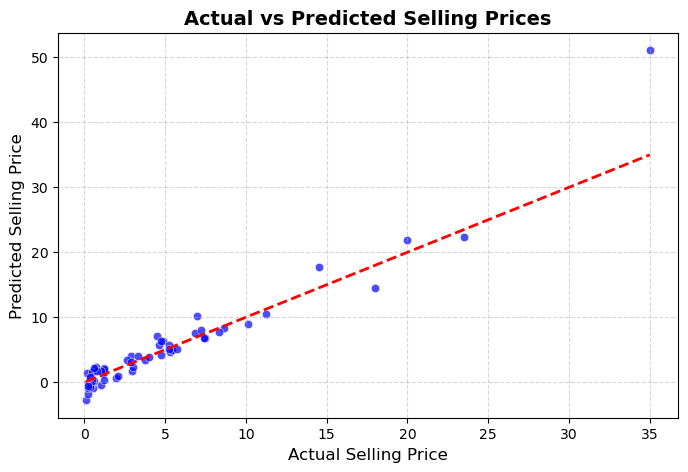

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=Y_test, y=ypred, alpha=0.7, color='blue')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)  # Perfect fit line

plt.xlabel('Actual Selling Price', fontsize=12)
plt.ylabel('Predicted Selling Price', fontsize=12)
plt.title('Actual vs Predicted Selling Prices', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#Second Model Random forest regressor 

In [ ]:
# Initializing and training the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, Y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Making predictions
rf_ypred = rf_model.predict(X_test)

In [ ]:
#exploring predicted test data
print(rf_ypred)

[ 0.346   9.904  16.135   0.409   3.114   0.1933  8.626  23.073   2.281
  2.572   1.1241  1.0204  7.5075  3.1895  1.338   4.252   6.0895  1.0819
  8.0772  1.2244  0.1696  7.3516  5.5845  3.3726  4.07    1.2106  5.359
  0.3641  0.7605  5.162  19.08    3.0569  0.7055  4.5895  0.7093 16.601
  2.5495  0.7018  8.1834  0.2765  4.5095  0.3624  0.4651  6.1875  5.066
  7.788   0.5503  0.7533 21.1255  0.2978  2.6373  2.9575  0.4413  6.9295
  0.4828  4.971   0.2807  6.5869  0.4605  0.6538]


In [ ]:
#exploring actual test data
print(Y_test)

175     0.38
289    10.11
52     18.00
148     0.52
216     2.90
199     0.12
276     8.65
63     23.50
28      1.95
203     2.95
114     1.15
121     1.05
11      6.85
246     3.75
112     1.15
297     4.00
74      4.90
107     1.25
267     8.35
109     1.20
190     0.20
12      7.50
71      4.50
19      2.65
89      4.75
110     1.20
300     5.30
178     0.35
122     1.05
252     5.40
86     35.00
298     3.35
134     0.65
287     5.75
133     0.72
79     14.50
255     3.00
140     0.60
91     11.25
191     0.20
4       4.60
195     0.18
156     0.48
249     5.25
81      4.75
16      7.25
170     0.40
129     0.78
59     19.99
187     0.25
281     2.10
213     2.90
176     0.35
60      6.95
152     0.50
214     5.25
193     0.20
285     7.40
174     0.38
141     0.60
Name: Selling_Price, dtype: float64


#MODEL EVALUATON

In [ ]:
# Evaluating the model
rf_mae = mean_absolute_error(Y_test, ypred)
rf_rmse = np.sqrt(mse)
rf_mse = mean_squared_error(Y_test, rf_ypred)
rf_r2 = r2_score(Y_test, rf_ypred)

# Displaying results
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Random Forest R² Score: {rf_r2:.4f}")
print(f"Random Forest Mean Squared Error: {rf_mse:.4f}")

Mean Absolute Error (MAE): 1.2994
Root Mean Squared Error (RMSE): 2.4453
Random Forest R² Score: 0.8821
Random Forest Mean Squared Error: 4.6886


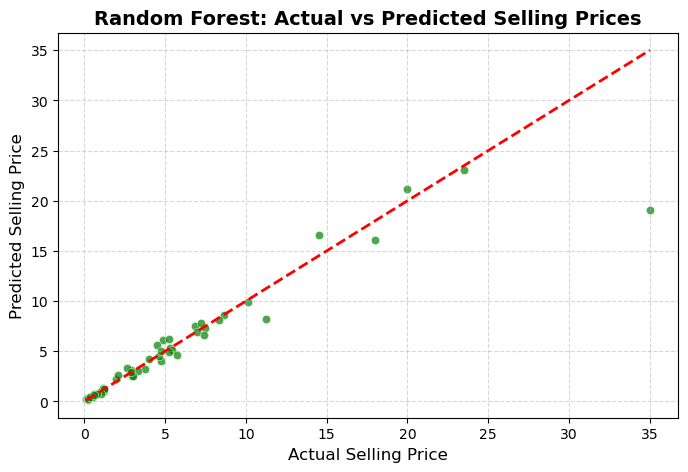

In [ ]:
# Plot Actual vs Predicted for Random Forest regressor model
plt.figure(figsize=(8, 5))
sns.scatterplot(x=Y_test, y=rf_ypred, alpha=0.7, color='green')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Selling Price', fontsize=12)
plt.ylabel('Predicted Selling Price', fontsize=12)
plt.title('Random Forest: Actual vs Predicted Selling Prices', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

##CONCLUSION 

#based on the evaluation metrics between the two models which is Random Forest  Regressor and Linear Regression for used car price prediction
#i have noticed that the Random Forest Regressor is the best performing model with the score of 88.2% of the variance in the target selling price ,compared to 85% by Linear Regression
#the mean squared error dropped from 5.98 down to 4.69,it means predictions are overall closer to the actual values
#Random Forest Regressor uses ensemble of decision tress that easily captures complex non-linear relationships and feature interactions unlike Linear Regression which assumes a strictly linear relationship between features and selling price  